<a href="https://colab.research.google.com/github/hayatu4islam/digital_phenotyping/blob/main/Tutorial_Human_Activity_Recognition_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**What is happening in this code block?**

Before an AI can understand human behavior, we have to prepare the data. The smartphone recorded two things: the Accelerometer (which measures linear motion, like moving forward) and the **Gyroscope** (which measures rotation, like tilting the phone).

This block of code performs four essential "cleaning" steps:



1.   **Loading and Trimming**: We load the raw sensor data. Because the accelerometer and gyroscope might have recorded at slightly different speeds, the code finds the minimum length between the two files and trims them so they match perfectly. It also throws away extra columns we don't need, like the specific brand of the phone.
2.   **Merging**: It glues the motion data and the rotation data together side-by-side into one master spreadsheet (pd.concat).


3.   **Normalizing (Leveling the Playing Field)**: It mathematically scales all the sensor numbers (cols_to_norm) so they fall within a similar range. If we didn't do this, a sensor that records using large numbers might artificially dominate the AI's attention.
4.   **Separating the "Answers" (One-Hot Encoding)**: We separate our input data (the sensor readings) from our target answers (y = data[['gt']], which tells us if the person was walking, sitting, etc.). We then convert those text labels into a mathematical format the computer can understand.
5.   **The 75/25 Split**: Finally, we split our data. We will use 75% of the data to teach the AI, and we will lock away the remaining 25% to test the AI later and see if it actually learned anything!









In [1]:
!pip install gdown

!gdown --id 10HOYqmWz0h6Z__QwXisBBkMDAMttY--3 -O Archive.zip

!unzip Archive.zip

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=10HOYqmWz0h6Z__QwXisBBkMDAMttY--3
From (redirected): https://drive.google.com/uc?id=10HOYqmWz0h6Z__QwXisBBkMDAMttY--3&confirm=t&uuid=5af91f60-e465-4d17-a454-2b700ff612a7
To: /content/Archive.zip
100% 612M/612M [00:05<00:00, 116MB/s]
Archive:  Archive.zip
  inflating: Phones_accelerometer.csv  
  inflating: __MACOSX/._Phones_accelerometer.csv  
  inflating: Phones_gyroscope.csv    
  inflating: __MACOSX/._Phones_gyroscope.csv  


In [2]:
!pip install keras
import os
import numpy as np
import pandas as pd
import time

start_time = time.time()

print('Loading data ...')
data1 = pd.read_csv('Phones_accelerometer.csv')
data2 = pd.read_csv('Phones_gyroscope.csv')

length1 = len(data1)
length2 = len(data2)
length = min(length1, length2)

data1 = data1.drop(labels = ['Arrival_Time','Creation_Time','Index', 'User'], axis=1)
data2 = data2.drop(labels = ['Arrival_Time','Creation_Time','Index', 'User','Model','Device'], axis=1)

data1 = data1.head(length)
data2 = data2.head(length)
data2.columns = ['x1', 'y1', 'z1', 'gt1']

data = pd.concat([data1, data2], axis=1)

to_drop = ['null']
data = data[~data['gt'].isin(to_drop)]
data = data[~data['gt1'].isin(to_drop)]
data = data.drop(labels = ['gt1'], axis=1)
data = data.iloc[::10, :]

cols_to_norm = ['x','y','z', 'x1','y1','z1']
data[cols_to_norm] = data[cols_to_norm].apply(lambda x: (x - x.mean()) / (x.max() - x.min()))

y = data[['gt']]
data = data.drop(labels = ['gt'], axis = 1)
data = pd.get_dummies(data)
parameters1 = len(data.columns)

y = pd.get_dummies(y)
parameters2 = len(y.columns)

data = np.array(data).astype(np.float32)
y = np.array(y).astype(np.float32)

m = len(data)
crossval = round(3*m/4)
train_data = data[0:crossval,:]
train_data_y = y[0:crossval,:]

test_data = data[crossval:,:]
test_data_y = y[crossval:,:]

X_train = train_data
X_train = np.reshape(X_train, (X_train.shape[0],1,X_train.shape[1]))
X_train = np.array(X_train)
y_train = train_data_y

X_test = test_data
X_test = np.reshape(X_test, (X_test.shape[0],1,X_test.shape[1]))
X_test = np.array(X_test)
y_test = test_data_y

Loading data ...


**Step 2: Building and Training the AI**

**What is happening in this code block?**
Now that our sensor data is clean, we need to build the "brain" that will analyze it.

This code constructs a specific type of Neural Network called an **LSTM (Long Short-Term Memory)** network. Standard AI models look at data one static snapshot at a time. But human movement like walking upstairs is a continuous flow. LSTMs are equipped with an internal memory, allowing them to understand sequences of motion over time.

Here is what the code executes:

1. **The Blueprint (_model.summary_)**: It builds a Sequential model stacking two LSTM memory layers, followed by a final decision layer (Dense) that will output a prediction for the 6 human activities.

2. **The Training Loop (_model.fit_)**: The AI begins studying the data. Each full pass over the data is called an Epoch. As the epochs progress, you will see the AI's error rate go down, and its accuracy go up.

3. **Saving the Results**: Finally, it plots the accuracy on a graph and saves the trained brain as a file (my_model.h5) so we can use it later without having to train it all over again!

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 24)          │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 12)             │         1,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │            78 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,982 (23.37 KB)

 Trainable params: 5,982 (23.37 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/3
30616/30616 ━━━━━━━━━━━━━━━━━━━━ 116s 4ms/step - accuracy: 0.3505 - loss: 0.3526
Epoch 2/3
30616/30616 ━━━━━━━━━━━━━━━━━━━━ 138s 4ms/step - accuracy: 0.5568 - loss: 0.2581
Epoch 3/3
30616/30616 ━━━━━━━━━━━━━━━━━━━━ 107s 3ms/step - accuracy: 0.5706 - loss: 0.2492
Accuracy: 41.73%
Epoch 1/3
15308/15308 ━━━━━━━━━━━━━━━━━━━━ 58s 4ms/step - accuracy: 0.5758 - loss: 0.2453
Epoch 2/3
15308/15308 ━━━━━━━━━━━━━━━━━━━━ 58s 4ms/step - accuracy: 0.5787 - loss: 0.2429
Epoch 3/3
15308/15308 ━━━━━━━━━━━━━━━━━━━━ 55s 4ms/step - accuracy: 0.5800 - loss: 0.2411
Accuracy: 41.67%
Epoch 1/3
7654/7654 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - accuracy: 0.5811 - loss: 0.2394
Epoch 2/3
7654/7654 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - accuracy: 0.5835 - loss: 0.2386
Epoch 3/3
7654/7654 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - accuracy: 0.5843 - loss: 0.2381
Accuracy: 40.94%


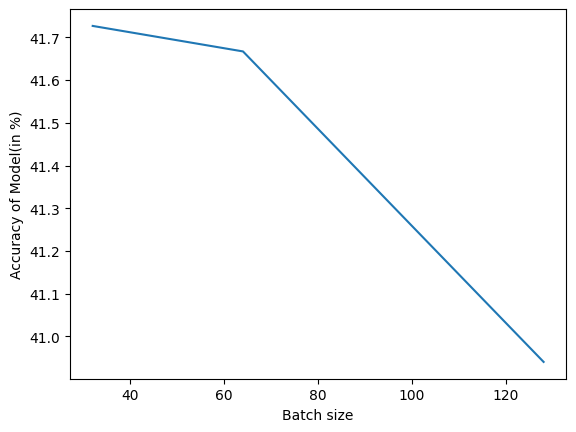

In [3]:
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

np.random.seed(7)

# Making the LSTM model
model = Sequential()
model.add(LSTM(24, input_shape = (1, parameters1),return_sequences=True))
model.add(LSTM(12))
model.add(Dense(6, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model.summary())

Accuracy_Arr = np.empty(0)
batch_size_Arr = np.empty(0)

# Fitting data
batch_side = 8
for i in range(5,batch_side):
  model.fit(X_train, y_train, epochs=3, batch_size=pow(2,i))
  scores = model.evaluate(X_test, y_test, verbose=0)
  print("Accuracy: %.2f%%" % (scores[1]*100))
  Accuracy_Arr = np.append(Accuracy_Arr,scores[1]*100)
  batch_size_Arr = np.append(batch_size_Arr, pow(2,i))

fig = plt.figure()
plt.plot(batch_size_Arr, Accuracy_Arr)
plt.xlabel("Batch size")
plt.ylabel("Accuracy of Model(in %)")
plt.show()
fig.savefig("Merged_data_Accuracy_vs_batch_size.png")

model.save("my_model.h5")